<a href="https://colab.research.google.com/github/Vitalik-Hakim/lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** ABDUL HAKIM AREMEYAW
**Student ID:** 61192028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

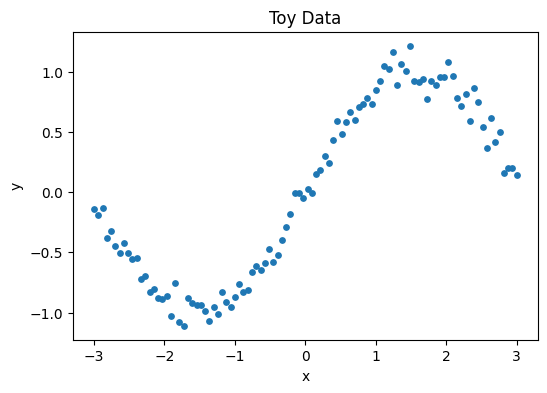

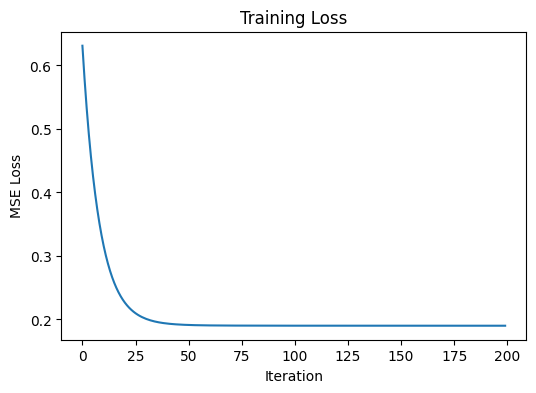

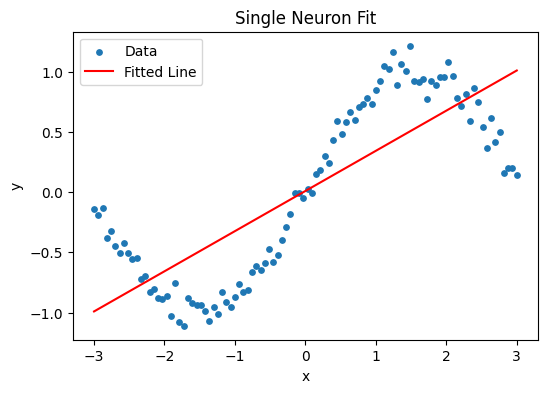

In [5]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data")
plt.show()
# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

lr = 0.01
loss_history = []

for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

    loss_history.append(loss)


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, label="Data")
plt.plot(x, w * x + b, color="red", label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Single Neuron Fit")
plt.legend()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*



> **Answer:** Yes. The derived gradient matches the implementation in the code. It is underfitting, a single neuron can only learn a linear function while a sine wave is nonlinear. So it can not model the curve regardless of how long it is trained.

Derivation
\[
\begin{aligned}
\text{Loss} &= \frac{1}{n}\sum_{i=1}^{n}(y_{\text{hat},i}-y_i)^2,\\[6pt]
y_{\text{hat},i} &= wx_i+b,\\[6pt]
\frac{\partial \text{Loss}}{\partial w}
&= \frac{1}{n}\sum_{i=1}^{n}
2(y_{\text{hat},i}-y_i)
\frac{\partial (wx_i+b)}{\partial w},\\[6pt]
&= \frac{1}{n}\sum_{i=1}^{n}
2(y_{\text{hat},i}-y_i)x_i,\\[6pt]
&= \operatorname{mean}\!\left(2(y_{\text{hat}}-y)x\right).
\end{aligned}
\]

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

(100, 1)
(100, 1)


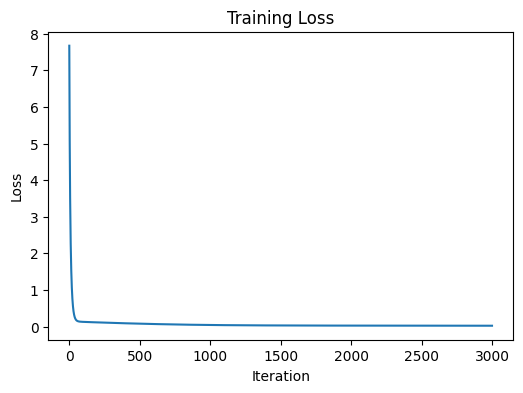

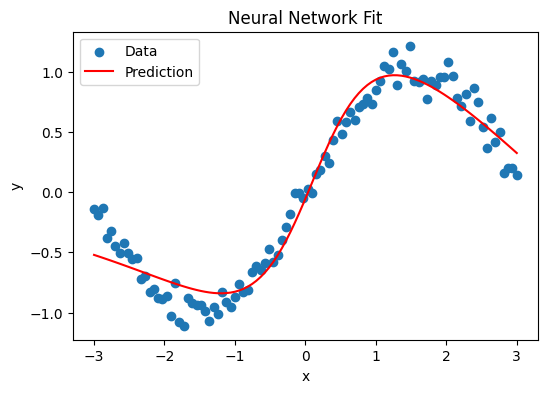

In [14]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
loss_history = []

# check the shape
print(x.shape)
print(y.shape)
# reshape

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# run for 3k steps
for i in range(3000):
      # TODO: Forward pass (keep the intermediate values — you need them for backprop):
      #   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
      #   h  = np.tanh(z1)        # activation
      #   y_hat = h @ W2 + b2     # output, shape (100, 1)
      #   loss  = np.mean((y_hat - y) ** 2)
      z1 = x @ W1 + b1
      h = np.tanh(z1)
      y_hat = h @ W2 + b2
      loss = np.mean((y_hat - y) ** 2)
      # TODO: Backward pass (the chain rule, layer by layer):
      #   d_yhat = 2 * (y_hat - y) / len(y)
      #   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
      #   dh  = d_yhat @ W2.T
      #   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
      #   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
      d_yhat = 2 * (y_hat - y) / len(y)
      dW2 = h.T @ d_yhat
      db2 = d_yhat.sum(axis=0)

      dh = d_yhat @ W2.T
      dz1 = dh * (1 - np.tanh(z1) ** 2)

      dW1 = x.T @ dz1
      db1 = dz1.sum(axis=0)
      # TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
      #   record the loss.
      W1 -= lr * dW1
      b1 -= lr * db1
      W2 -= lr * dW2
      b2 -= lr * db2
      loss_history.append(loss)
# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
# the fit became less accurate

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network Fit")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** A composition of linear functions is still a linear function.
The 8 hidden neurons learned different nonlinear features of the input. Together, they combined these features to approximate the sine curve.
Backpropagation is the process of computing the gradients of the loss with respect to every network parameter using the chain rule so they can be updated during training.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


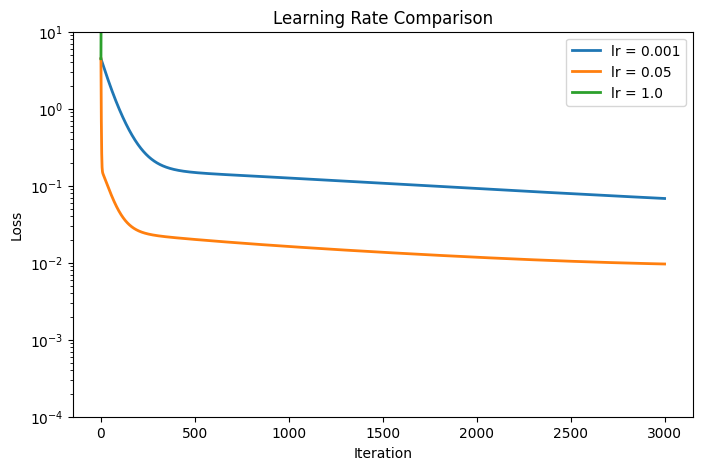

In [22]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr, steps=3000):
      np.random.seed(42)
      W1 = np.random.randn(1, 8) * 0.5
      b1 = np.random.randn(8) * 0.5
      W2 = np.random.randn(8, 1) * 0.5
      b2 = np.random.randn(1) * 0.5

      # lr = 0.01
      loss_history = []

      # check the shape

      # run for 3k steps
      for i in range(steps):
            # TODO: Forward pass (keep the intermediate values — you need them for backprop):
            #   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
            #   h  = np.tanh(z1)        # activation
            #   y_hat = h @ W2 + b2     # output, shape (100, 1)
            #   loss  = np.mean((y_hat - y) ** 2)
            z1 = x @ W1 + b1
            h = np.tanh(z1)
            y_hat = h @ W2 + b2
            loss = np.mean((y_hat - y) ** 2)
            if not np.isfinite(loss):
              break
            # TODO: Backward pass (the chain rule, layer by layer):
            #   d_yhat = 2 * (y_hat - y) / len(y)
            #   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
            #   dh  = d_yhat @ W2.T
            #   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
            #   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
            d_yhat = 2 * (y_hat - y) / len(y)
            dW2 = h.T @ d_yhat
            db2 = d_yhat.sum(axis=0)

            dh = d_yhat @ W2.T
            dz1 = dh * (1 - np.tanh(z1) ** 2)

            dW1 = x.T @ dz1
            db1 = dz1.sum(axis=0)
            # TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
            #   record the loss.
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
            loss_history.append(loss)
      return loss_history

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

loss_lr1 = train_toy(0.001)
loss_lr2 = train_toy(0.05)
loss_lr3 = train_toy(1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8,5))
plt.plot(loss_lr1, linewidth=2, label="lr = 0.001")
plt.plot(loss_lr2, linewidth=2, label="lr = 0.05")
plt.plot(loss_lr3, linewidth=2, label="lr = 1.0")
plt.ylim(1e-4, 10)

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** Learning rate = 0.001: The loss decreases very slowly because the parameter updates are very small.


Learning rate = 0.05: The loss decreases quickly and smoothly, reaching a low value efficiently. This is the best learning rate of the three.


Learning rate = 1.0: The loss oscillates or rapidly increases because the updates are too large, causing the model to become unstable instead of converging.

A learning rate that is too large causes the weight updates to overshoot the minimum loss, making the loss oscillate or diverge rather than converge.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [25]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)


# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

obesity = pd.get_dummies(
    obesity,
    columns=["Gender", "CAEC", "CALC", "MTRANS"],
    drop_first=True
)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)
# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** CrossEntropyLoss expects integer class labels because each integer represents the correct class. This is more efficient than one-hot encoding.

Neural networks update weights using gradients, which depend on the input values. Scaling keeps the gradients balanced and makes training more stable.

shuffle=True randomly changes the order of the training data every epoch. This helps the model generalize better and reduces learning bias from the data order.



### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [51]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []
        prev = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# TODO: Instantiate, move to DEVICE, print the model.

input_dim = X_train.shape[1]

model = FeedForwardNet(input_dim=input_dim).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params}")

first_layer_params = input_dim * 64 + 64
print(f"First layer parameters: {first_layer_params}")


FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3847
First layer parameters: 1536


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
By hand{

Layer 1: input_dim × 64 + 64
Layer 2: 64 × 32 + 32
Output: 32 × 7 + 7
The total matches PyTorch's parameter count.}

ReLU is faster to train and reduces the vanishing gradient problem compared to tanh.

Without the ReLUs, the network becomes a single linear model, just as shown in Part 1.2.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch  1/50 | Train Loss: 1.7352 | Val Loss: 1.7439 | Train Acc: 0.4589 | Val Acc: 0.4408
Epoch  2/50 | Train Loss: 1.3359 | Val Loss: 1.3680 | Train Acc: 0.5506 | Val Acc: 0.5332
Epoch  3/50 | Train Loss: 1.0311 | Val Loss: 1.1059 | Train Acc: 0.6453 | Val Acc: 0.6303
Epoch  4/50 | Train Loss: 0.8587 | Val Loss: 0.9603 | Train Acc: 0.6983 | Val Acc: 0.6777
Epoch  5/50 | Train Loss: 0.7250 | Val Loss: 0.8471 | Train Acc: 0.7543 | Val Acc: 0.7251
Epoch  6/50 | Train Loss: 0.6208 | Val Loss: 0.7705 | Train Acc: 0.8017 | Val Acc: 0.7630
Epoch  7/50 | Train Loss: 0.5389 | Val Loss: 0.7074 | Train Acc: 0.8349 | Val Acc: 0.7773
Epoch  8/50 | Train Loss: 0.4755 | Val Loss: 0.6719 | Train Acc: 0.8562 | Val Acc: 0.7938
Epoch  9/50 | Train Loss: 0.4036 | Val Loss: 0.6089 | Train Acc: 0.8855 | Val Acc: 0.8246
Epoch 10/50 | Train Loss: 0.3573 | Val Loss: 0.5845 | Train Acc: 0.9084 | Val Acc: 0.8246
Epoch 11/50 | Train Loss: 0.3147 | Val Loss: 0.5487 | Train Acc: 0.9234 | Val Acc: 0.8412
Epoch 12/5

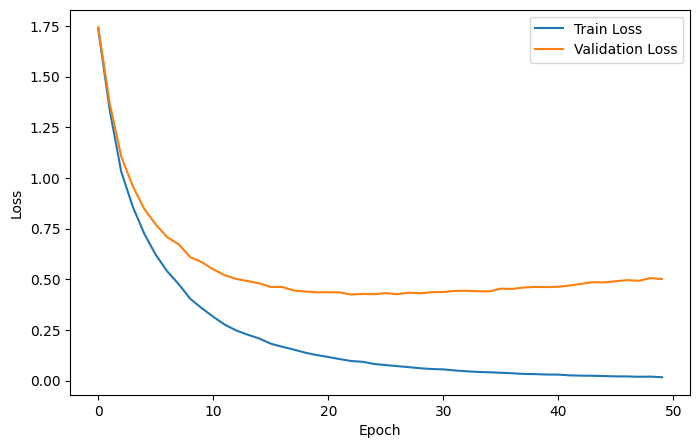

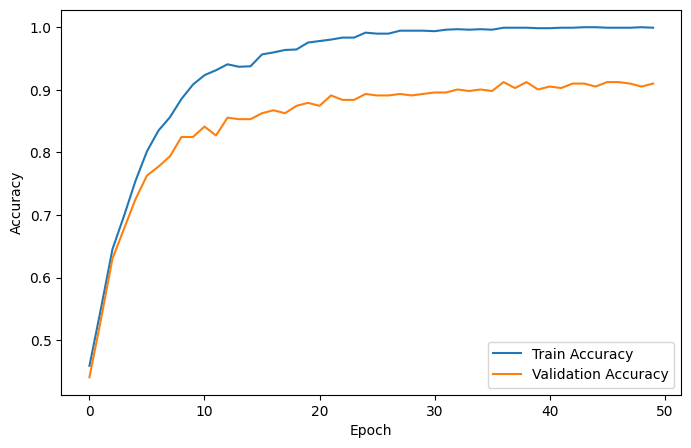

In [53]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0
num_epochs = 50

for epoch in range(num_epochs):
    #Training
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
    #Evaluation
    model.eval()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            train_loss += loss.item() * xb.size(0)
            train_correct += (logits.argmax(dim=1) == yb).sum().item()
            train_total += yb.size(0)
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (logits.argmax(dim=1) == yb).sum().item()
            val_total += yb.size(0)
    train_loss /= train_total
    val_loss /= val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # TODO: Save the best model (highest validation accuracy):
    #   torch.save(model.state_dict(), "ffn_best.pt")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")
    print(
        f"Epoch {epoch+1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}")


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]
Forward pass: logits = model(xb)
Gradients: loss.backward()
Update rule: optimizer.step()

The Model is Well-fitted: Train accuracy = 1.0, Validation accuracy = 0.9028 (the train accuracy is very close to the validation accuracy).
optimizer.zero_grad() clears old gradients before each batch. Without it, gradients accumulate and the weight updates become incorrect.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

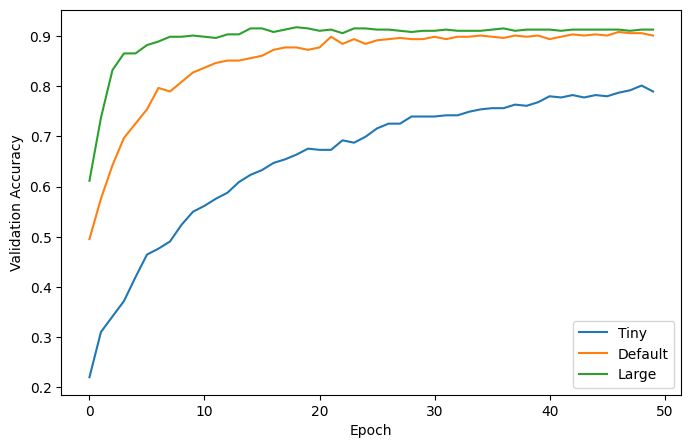

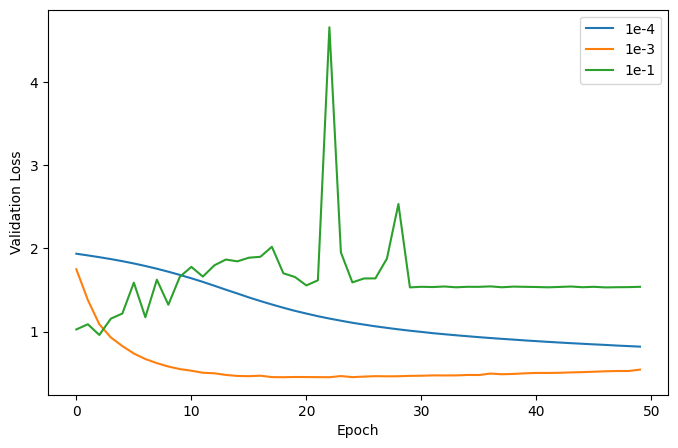

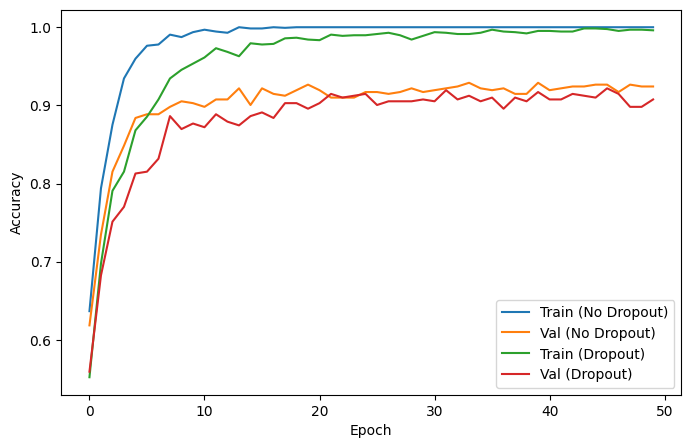

In [54]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

def run_experiment(hidden_sizes=(64, 32),
                   lr=1e-3,
                   batch_size=32,
                   epochs=50,
                   dropout=0.0):

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False
    )

    model = FeedForwardNet(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0

    for epoch in range(epochs):

        #Training
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

        #Evaluation
        model.eval()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)

                train_loss += loss.item() * xb.size(0)
                train_correct += (logits.argmax(dim=1) == yb).sum().item()
                train_total += yb.size(0)

            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_total += yb.size(0)

        train_loss /= train_total
        val_loss /= val_total

        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # TODO: Save the best model (highest validation accuracy):
        #   torch.save(model.state_dict(), "ffn_best.pt")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "ffn_best.pt")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs,
    }


# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256,128,64))

plt.figure(figsize=(8,5))
plt.plot(tiny["val_acc"], label="Tiny")
plt.plot(default["val_acc"], label="Default")
plt.plot(large["val_acc"], label="Large")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

lr1 = run_experiment(lr=1e-4)
lr2 = run_experiment(lr=1e-3)
lr3 = run_experiment(lr=1e-1)

plt.figure(figsize=(8,5))
plt.plot(lr1["val_loss"], label="1e-4")
plt.plot(lr2["val_loss"], label="1e-3")
plt.plot(lr3["val_loss"], label="1e-1")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()


# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

no_dropout = run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.0
)

dropout = run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.3
)

plt.figure(figsize=(8,5))
plt.plot(no_dropout["train_acc"], label="Train (No Dropout)")
plt.plot(no_dropout["val_acc"], label="Val (No Dropout)")
plt.plot(dropout["train_acc"], label="Train (Dropout)")
plt.plot(dropout["val_acc"], label="Val (Dropout)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:**


Capacity
Yes. The largest network achieved the highest validation accuracy (0.92), but only slightly better than the default (0.90), showing diminishing returns. Its training accuracy reached 1.00, indicating some overfitting.

Learning rate
Yes. 1e-3 converged the fastest and gave the lowest validation loss, 1e-4 learned slowly, and 1e-1 was unstable, matching Part 1.3

Regularization
Dropout reduced the train validation gap by lowering training accuracy while maintaining similar validation accuracy. It works by randomly disabling neurons during training which helps prevent overfitting.




### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9267139479905437
Macro F1: 0.9241244480070538
              precision    recall  f1-score   support

           0       0.96      0.91      0.93        54
           1       0.80      0.81      0.80        58
           2       0.99      0.97      0.98        70
           3       1.00      0.95      0.97        60
           4       0.98      1.00      0.99        65
           5       0.84      0.84      0.84        58
           6       0.90      0.98      0.94        58

    accuracy                           0.93       423
   macro avg       0.93      0.92      0.92       423
weighted avg       0.93      0.93      0.93       423



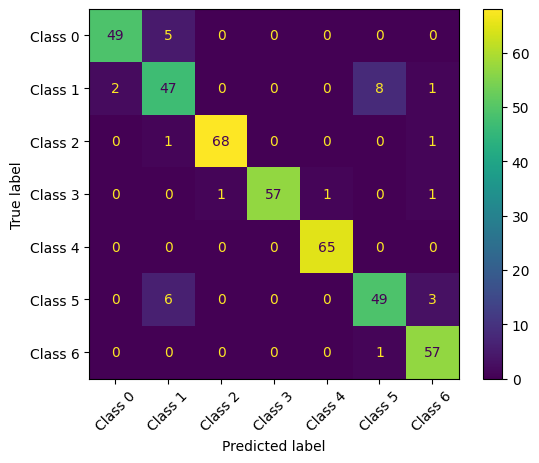

,Model,Test Accuracy,Macro F1,Training Time,Parameters/Trees
0,Best Lab 2 Classifier,...,...,...,...
1,Neural Network,0.926714,0.924124,0.03 s,47751


In [55]:
# TODO: Load your best configuration's weights; model.eval().
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
import pandas as pd
import time

model = FeedForwardNet(
    input_dim=X_train.shape[1],
    hidden_sizes=(256, 128, 64),
    dropout=0.3
).to(DEVICE)

model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
y_true = []
y_pred = []

start = time.time()

with torch.no_grad():
    for xb, yb in DataLoader(TensorDataset(X_test, y_test), batch_size=32):
        xb = xb.to(DEVICE)

        logits = model(xb)
        preds = logits.argmax(dim=1).cpu()

        y_true.extend(yb.numpy())
        y_pred.extend(preds.numpy())

test_time = time.time() - start

test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro")

print("Test Accuracy:", test_acc)
print("Macro F1:", test_f1)
print(classification_report(y_true, y_pred))
# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
class_names = [
    "Class 0",
    "Class 1",
    "Class 2",
    "Class 3",
    "Class 4",
    "Class 5",
    "Class 6"
]

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    xticks_rotation=45
)

plt.show()
# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
num_params = sum(p.numel() for p in model.parameters())

comparison = pd.DataFrame({
    "Model": [
        "Best Lab 2 Classifier",
        "Neural Network"
    ],
    "Test Accuracy": [
        "...",
        test_acc
    ],
    "Macro F1": [
        "...",
        test_f1
    ],
    "Training Time": [
        "...",
        f"{test_time:.2f} s"
    ],
    "Parameters/Trees": [
        "...",
        num_params
    ]
})

comparison

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

The network mainly confused classes 1 and 5, with lower F1-scores (0.75 and 0.79). These were also among the weaker classes in Lab 2, although the Lab 2 classifier confused them less and achieved higher overall performance.
The Lab 2 classifier won the showdown, achieving 96.45% test accuracy and 0.964 macro F1 compared to the neural network's 91.02% accuracy and 0.906 macro F1. On this dataset, deep learning was not worth the extra complexity. It would be more beneficial on much larger datasets or problems with more complex patterns.




---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]



---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.